This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [2]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from sklearn.metrics import confusion_matrix
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [3]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/ce_groups')

In [4]:
files_calc = glob.glob('*.dat')

In [5]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')
        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')
    # for f in files_exp:
        # df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        # raw_data_points.append(df.values.ravel())
        # labels.write(f[0])
        # labels.write('\n')
        
raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

2


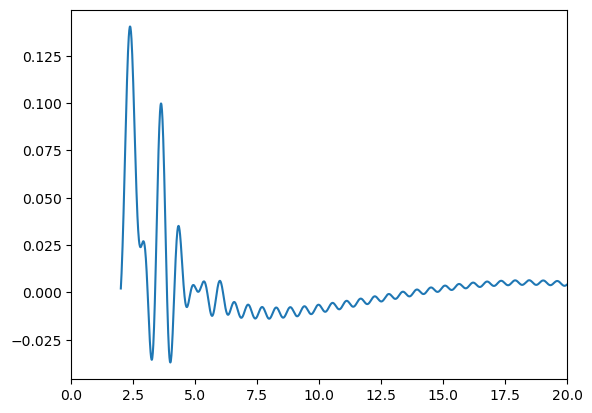

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(0,20)
ax.plot(np.arange(len(data_points[113,:]))/100+2, data_points[113,:])
print(labels[113])


In [7]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

In [8]:
# Tuning of the model

model = Sequential()
# Add the convolutional layers
model.add(Conv1D(filters=32, kernel_size=256, activation='relu', input_shape=(1800, 1))) # 256, 32
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.5))
model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32
model.add(Dropout(0.5))

model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 16

# Flatten the output of the convolutional layers
model.add(Flatten())

# Add the fully connected layers
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01

# Compile the model
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1545, 32)          8224      
                                                                 
 batch_normalization (BatchN  (None, 1545, 32)         128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 772, 32)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 772, 32)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 741, 64)           65600     
                                                                 
 dropout_1 (Dropout)         (None, 741, 64)           0

In [9]:
# Train the model
num_epochs = 40

checkpoint = ModelCheckpoint("ce_calc_2-20_test.hdf5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpoint], batch_size=256)
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/20


2023-08-08 14:49:00.033250: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


63/63 [==============================] - ETA: 0s - loss: 1.9783 - accuracy: 0.5786
Epoch 1: val_accuracy improved from -inf to 0.50500, saving model to ce_calc_2-20.hdf5
63/63 [==============================] - 87s 1s/step - loss: 1.9783 - accuracy: 0.5786 - val_loss: 2.3797 - val_accuracy: 0.5050
Epoch 2/20
63/63 [==============================] - ETA: 0s - loss: 0.8706 - accuracy: 0.7534
Epoch 2: val_accuracy improved from 0.50500 to 0.76800, saving model to ce_calc_2-20.hdf5
63/63 [==============================] - 93s 1s/step - loss: 0.8706 - accuracy: 0.7534 - val_loss: 2.1460 - val_accuracy: 0.7680
Epoch 3/20
63/63 [==============================] - ETA: 0s - loss: 0.7115 - accuracy: 0.7934
Epoch 3: val_accuracy did not improve from 0.76800
63/63 [==============================] - 84s 1s/step - loss: 0.7115 - accuracy: 0.7934 - val_loss: 2.2025 - val_accuracy: 0.5715
Epoch 4/20
63/63 [==============================] - ETA: 0s - loss: 0.6133 - accuracy: 0.8297
Epoch 4: val_accurac

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


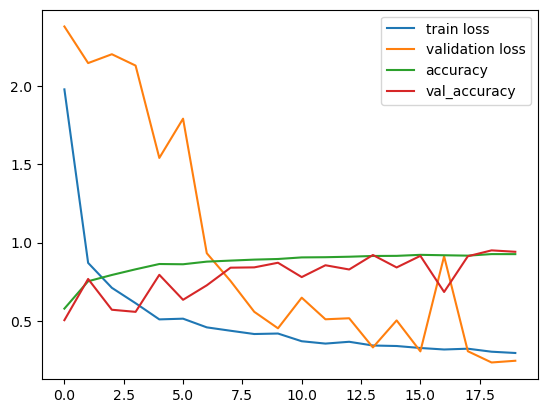

In [10]:
print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [12]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('ce_calc_2-20_test.hdf5')

In [13]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)

63/63 [==============================] - 4s 69ms/step


Confusion matrix, without normalization
[[492   0   0   0   0   0   0   0   0]
 [  0 575   0   0   0   0   0   0   0]
 [  0   0 394   0   0   0   0   0   0]
 [  0   0   0 271   0   0   0   0   0]
 [  0   0   0  16 115   4   0   0   0]
 [  0   0   0   1  27  54   0   0   0]
 [  0   0   0   0   1  32   0   0   0]
 [  0   0   0   0   0  12   0   0   0]
 [  0   0   0   0   0   2   0   4   0]]


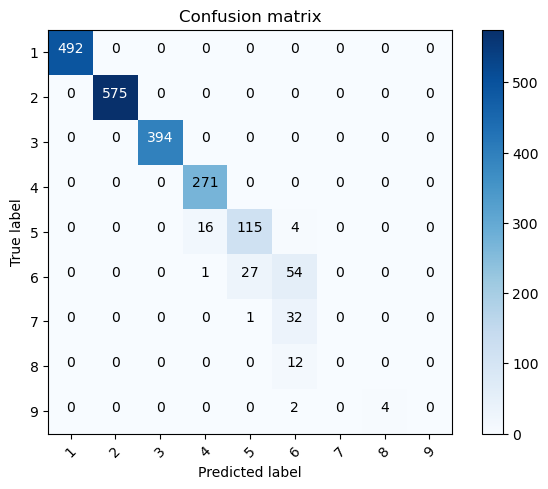

In [14]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()